# pyCSLDV showcase: a measured ODS

**A continuous scanning laser Doppler vibrometry measurement processed end to end.**

The [Showcase](Showcase.ipynb) notebook walks through the workflow on a *simulated*
measurement, where the answer is known in advance. This one runs the same chain on a real
measurement: a 10 s CSLDV acquisition of a rectangular plate excited at 4527 Hz, recorded
with the original LabVIEW/MATLAB CSLDV suite, and compares the reconstructed operating
deflection shape with the one that suite computed from the very same samples.

1. **The export** — reading the measurement, and matching the mirror channels,
2. **The scan** — the physical extent of the scanned region and the path the laser took,
3. **The sidebands** — checking the excitation frequency before demodulating,
4. **Reconstruction** — the ODS from the measured velocity,
5. **Validation** — against the ODS of the original suite, using the MAC.

> **The dataset** is a measurement provided by Joshua Bartlett (FAST Laboratory, Texas A&M
> University). It is about 80 MB, is **not part of this repository**, and will be published
> separately on Zenodo. To run this notebook, place the exported files in `examples/data/`.
>
> **Origin:** pyCSLDV is an independent Python reimplementation of the *CSLDV Vibration
> Measurement & Simulation Suite* by Joshua Bartlett and Pablo Tarazaga (Texas A&M
> University), published under CC-BY-4.0 at
> [zenodo.org/records/21301126](https://zenodo.org/records/21301126)
> (DOI: [10.5281/zenodo.21301126](https://doi.org/10.5281/zenodo.21301126)). The original
> material has been modified; the differences are listed under *Origin and attribution* in
> the README. The initial Python implementation was written with Claude (Anthropic) and has
> not yet been reviewed by the authors of the original suite. The package is at an alpha
> stage.

## 0. The measurement and its files

A measurement is exported as a set of files named after the excitation frequency:

| file | content |
| --- | --- |
| `TimeResponse_4527.txt` | the measurement: mirror positions [mm] and LDV velocity [mm/s] |
| `LissajousPattern_4527.txt` | the commanded scan path, in mirror drive volts |
| `4527.xlsx` | the ODS and FRF the original suite reconstructed from this measurement |
| `GUISettings_4527.png` | screenshot of the acquisition front panel |

The last one matters, because **the acquisition parameters are not stored in the exported
data files** and have to be read off the front panel:

| parameter | value | |
| --- | --- | --- |
| sampling rate | 100 kS/s | 10 s record, 1e6 samples |
| excitation frequency | 4527 Hz | a single frequency, hence the file names |
| scan frequencies | 1.4 Hz and 20 Hz | Lissajous, closure period 5 s |
| spectral sideband quantity | 12 | the Chebyshev `order` of the reconstruction |
| ODS point density | 150 | grid of the exported reference shape |

Three further constants came with the dataset by e-mail — a rotation angle of 1.60368°, a
mirror scaling factor of 0.5 V/° and a mirror spacing distance of 14.7 mm. They describe how
the mirror angles map onto the specimen surface; the exported positions are already in mm,
so the reconstruction does not need them.

The files are read with `examples/csldv_suite_export.py`, which is deliberately **not** part
of the `pycsldv` package: the package works on plain arrays, and this format belongs to one
particular acquisition front end. What pyCSLDV does provide for measured data are the two
steps that any format needs — `normalize_scan` and `dominant_frequency`.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import pycsldv
from examples.csldv_suite_export import read_time_response, read_ods_export

data = Path('examples/data') if Path('examples/data').exists() else Path('data')
if not (data / 'TimeResponse_4527.txt').exists():
    raise FileNotFoundError(f'place the exported measurement files in {data.resolve()}')

fs = 100_000.0      # sampling rate [S/s]
fx, fy = 1.4, 20.0  # scan frequencies [Hz]
fz = 4527.0         # excitation frequency [Hz]
order = 12          # spectral sideband quantity

pycsldv.__version__

'0.1.0'

## 1. Reading the export

`read_time_response` reads the six columns of the measurement. The axis naming in these
files is not consistent — the column labelled *X-Mirror* follows the frequency the
acquisition GUI calls the *Y-Mirror Scanning Frequency* — so the reader matches the two
mirror channels to the scan frequencies **by their measured frequency**, and says so when
the file order and the labels disagree.

Getting that pairing wrong is silent and fatal: the demodulation would look for the shape
along the wrong axis and return something plausible and meaningless.

In [2]:
t, x, y, velocity = read_time_response(data / 'TimeResponse_4527.txt', fx=fx, fy=fy)

print(f'{len(t)} samples, {t[-1] + t[1]:.0f} s at {1 / t[1] / 1000:.0f} kS/s')
print(f'x mirror scans at {pycsldv.dominant_frequency(x, fs):.4g} Hz, '
      f'y mirror at {pycsldv.dominant_frequency(y, fs):.4g} Hz')

1000000 samples, 10 s at 100 kS/s
x mirror scans at 1.4 Hz, y mirror at 20 Hz


/home/jankoslavic/_d/cld/ContinuousScanningLDV/pyCSLDV/examples/csldv_suite_export.py:96: UserWarning: the mirror columns are swapped with respect to the given scan frequencies: the first column scans at 20 Hz and the second at 1.4 Hz; assigning the second column to x (fx = 1.4 Hz) and the first to y (fy = 20 Hz)
  warnings.warn(


## 2. The scan

`x` and `y` come back on the normalized domain $[-1, 1]$ that the reconstruction works on.
Read without normalization they are the mirror positions in mm, and `normalize_scan` reports
the offset and amplitude it removes — which is the physical extent of the scanned region:

In [3]:
_, x_mm, y_mm, _ = read_time_response(data / 'TimeResponse_4527.txt',
                                      fx=fx, fy=fy, normalize=False)
extent = {}
for axis, position, f in (('x', x_mm, fx), ('y', y_mm, fy)):
    _, offset, amplitude = pycsldv.normalize_scan(position, f, fs)
    extent[axis] = (offset, amplitude)
    print(f'{axis} axis ({f:4.1f} Hz): centre {offset:+7.3f} mm, amplitude {amplitude:6.3f} mm')
print(f"\nscanned region: {2 * extent['x'][1]:.1f} mm x {2 * extent['y'][1]:.1f} mm")

x axis ( 1.4 Hz): centre  -0.011 mm, amplitude 35.487 mm
y axis (20.0 Hz): centre  +0.737 mm, amplitude  7.274 mm

scanned region: 71.0 mm x 14.5 mm


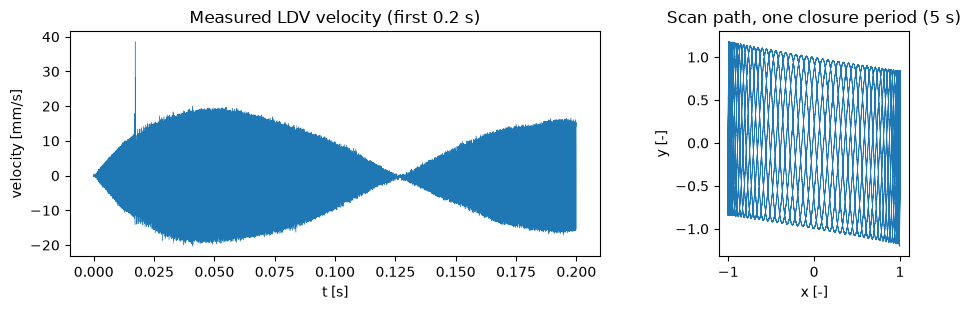

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), width_ratios=(1.6, 1))

one_period = slice(0, int(fs * pycsldv.scan_period(fx, fy)))
axes[0].plot(t[:20_000], velocity[:20_000], linewidth=0.3)
axes[0].set(xlabel='t [s]', ylabel='velocity [mm/s]',
            title='Measured LDV velocity (first 0.2 s)')
pycsldv.plot_trajectory(x[one_period], y[one_period], ax=axes[1])
axes[1].set_title('Scan path, one closure period (5 s)')
fig.tight_layout()

The velocity is amplitude-modulated by the deflection shape as the spot sweeps across it —
the same envelope as in the simulated showcase, now with a measurement transient near
0.017 s.

The scan path is not quite the separable $\cos \times \cos$ pattern that was commanded: the
measured fast axis tapers towards one end of the slow axis. Its 20 Hz amplitude is in fact
constant to 0.6 %, but 17 % of that channel (in rms) sits at 1.4 Hz, its harmonics, and
$20 \pm 1.4$ Hz — the slow mirror leaking into the fast mirror's position, which is the
cross-axis geometry that the 14.7 mm mirror spacing describes. The commanded path in
`LissajousPattern_4527.txt` shows none of it.

The reconstruction is insensitive to this, since it uses only the *phase* of each mirror
signal at its scan frequency. It is worth knowing about all the same, because a coupling of
this size distorts the normalized domain that the shape is expressed on.

## 3. The sidebands

The deflection shape is encoded in the sidebands at $f_z \pm n f_x \pm m f_y$ around the
excitation frequency. They are worth a look before demodulating, because they show whether
the frequency read off the front panel is the one the structure was actually driven at: the
comb has to be **symmetric** about it.

Here the largest line near the response sits at 4529.8 Hz, which could be mistaken for the
carrier — but the comb is symmetric about 4527.0 Hz to within 0.1 %. The shape happens to be
symmetric about the scan centre, so its odd-order coefficients nearly vanish and the
$n = 2$ pair dominates the carrier itself.

symmetry of the comb about the assumed carrier:
  n = 0:    6.1984    6.1984 mm/s   ratio 1.000
  n = 1:    0.3732    0.3703 mm/s   ratio 0.992
  n = 2:   10.2678   10.2789 mm/s   ratio 0.999
  n = 3:    0.0199    0.0371 mm/s   ratio 0.538
  n = 4:    0.8946    0.8816 mm/s   ratio 0.985


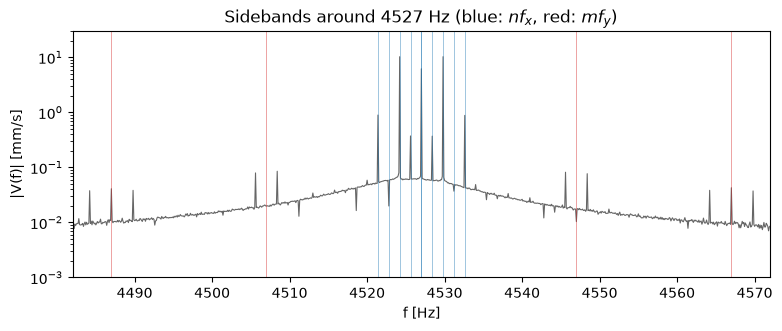

In [5]:
spectrum = 2 * np.abs(np.fft.rfft(velocity)) / len(velocity)
freq = np.fft.rfftfreq(len(velocity), 1 / fs)
bin_of = lambda f: round(f / (freq[1] - freq[0]))

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.semilogy(freq, spectrum, linewidth=0.8, color='0.4')
for n in range(5):
    for sign in (1, -1):
        ax.axvline(fz + sign * n * fx, color='tab:blue', linewidth=0.6, alpha=0.5)
for m in (1, 2):
    for sign in (1, -1):
        ax.axvline(fz + sign * m * fy, color='tab:red', linewidth=0.6, alpha=0.5)
ax.set(xlabel='f [Hz]', ylabel='|V(f)| [mm/s]', xlim=(fz - 45, fz + 45), ylim=(1e-3, 30),
       title=f'Sidebands around {fz:.0f} Hz (blue: $n f_x$, red: $m f_y$)')

print('symmetry of the comb about the assumed carrier:')
for n in range(5):
    lower, upper = spectrum[bin_of(fz - n * fx)], spectrum[bin_of(fz + n * fx)]
    print(f'  n = {n}:  {lower:8.4f}  {upper:8.4f} mm/s   ratio {min(lower, upper) / max(lower, upper):.3f}')

The $f_y$ sidebands (red) barely rise above the noise floor, while the $f_x$ sidebands (blue)
reach 10 mm/s: the shape varies along the 1.4 Hz axis and is nearly uniform across the 20 Hz
one. That is a property of this particular mode, and it means the reconstruction below is
essentially one-dimensional.

## 4. Reconstruction

`demodulate_ods` projects the velocity onto every sideband up to `order` and returns the
complex Chebyshev coefficients of the shape. The mirror phases — the inertial lag of the
galvos — are estimated from the measured mirror signals themselves, which is what the
feedback columns of the export are for.

In [6]:
C = pycsldv.align_phase(pycsldv.demodulate_ods(velocity, x, y, fs, fx, fy, fz, order=order))

print('|C[n, m]|, n along the 1.4 Hz axis, m along the 20 Hz axis:')
print(np.array2string(np.abs(C[:6, :4]), precision=3, suppress_small=True))

|C[n, m]|, n along the 1.4 Hz axis, m along the 20 Hz axis:
[[ 6.262  0.007  0.041  0.001]
 [ 0.618  0.148  0.004  0.002]
 [19.73   0.009  0.044  0.001]
 [ 0.11   0.023  0.001  0.001]
 [ 1.384  0.004  0.01   0.003]
 [ 0.016  0.002  0.002  0.003]]


The coefficients drop off immediately along `m` and are largest at `n = 2`: about one full
wave along the long axis, and no structure across it. `align_phase` has rotated the dominant
coefficient onto the real axis, so an essentially real (normal) mode leaves the imaginary
part near zero — which is what the lower panel shows, on the same colour scale as the upper
one.

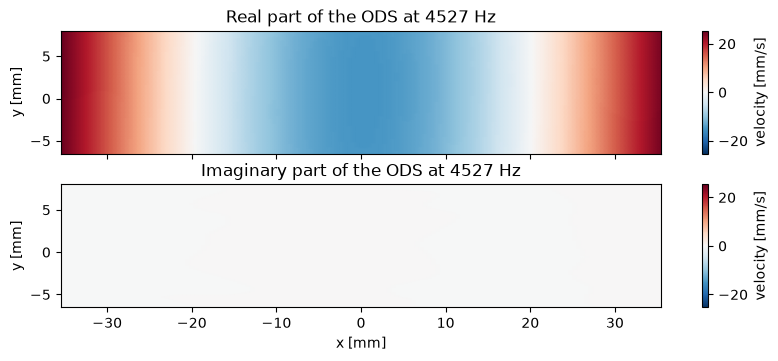

In [7]:
grid_x, grid_y, z = pycsldv.evaluate_ods(C, resolution=150)
# the normalized domain [-1, 1] back onto the scanned surface [mm]
mm = lambda grid, axis: extent[axis][0] + grid * extent[axis][1]
scale = np.abs(z.real).max()

fig, axes = plt.subplots(2, 1, figsize=(9, 3.6), sharex=True)
for ax, part, title in zip(axes, (z.real, z.imag), ('Real', 'Imaginary')):
    mesh = ax.pcolormesh(mm(grid_x, 'x').T, mm(grid_y, 'y').T, part.T, cmap='RdBu_r',
                         shading='gouraud', vmin=-scale, vmax=scale)
    fig.colorbar(mesh, ax=ax, label='velocity [mm/s]')
    ax.set(title=f'{title} part of the ODS at {fz:.0f} Hz', ylabel='y [mm]', aspect='equal')
axes[1].set_xlabel('x [mm]')
fig.tight_layout()

## 5. Validation against the original suite

The workbook of the same measurement holds the ODS that the LabVIEW/MATLAB suite
reconstructed from these very samples, on a 150 x 150 grid. `read_ods_export` reads it, so
two independent implementations can be compared on identical data with the MAC.

The workbook follows its own axis convention — its `ODS_X` is the short (20 Hz) axis, the one
`demodulate_ods` calls `y` — so the reference is transposed before comparing.

In [8]:
reference_x, reference_y, reference = read_ods_export(data / '4527.xlsx')
print(f'reference grid {reference.shape}, '
      f'axis 0 spans {reference_x.min():.3f} to {reference_x.max():.3f} (short axis), '
      f'axis 1 spans {reference_y.min():.3f} to {reference_y.max():.3f} (long axis)')

mac = pycsldv.mac(reference.real, z.real.T)
print(f'\nMAC(suite, pyCSLDV) = {mac:.4f}')

reference grid (150, 150), axis 0 spans -0.442 to 0.442 (short axis), axis 1 spans -2.293 to 2.293 (long axis)

MAC(suite, pyCSLDV) = 0.9905


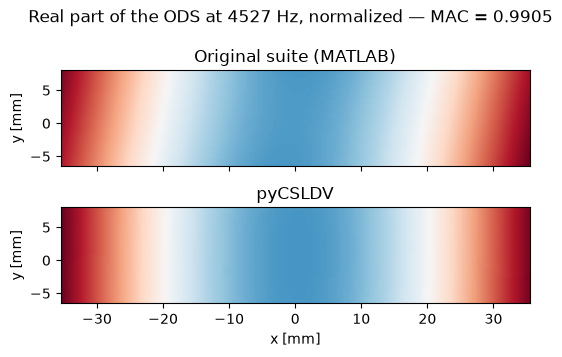

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(9, 3.6), sharex=True)
for ax, shape, title in zip(axes, (reference.real, z.real.T),
                            ('Original suite (MATLAB)', 'pyCSLDV')):
    ax.pcolormesh(mm(grid_x, 'x').T, mm(grid_y, 'y').T, shape / np.abs(shape).max(),
                  cmap='RdBu_r', shading='gouraud', vmin=-1, vmax=1)
    ax.set(title=title, ylabel='y [mm]', aspect='equal')
axes[1].set_xlabel('x [mm]')
fig.suptitle(f'Real part of the ODS at {fz:.0f} Hz, normalized — MAC = {mac:.4f}')
fig.tight_layout()

## What this shows, and what it does not

The two implementations agree on the measured shape (MAC 0.99), which checks the pyCSLDV
processing chain against the original one on real data rather than on a simulation. The same
comparison runs as a test in `tests/test_measured_reference.py`, which skips while the
dataset is absent. Four caveats belong with that number:

- **The shape is one-dimensional here.** The 20 Hz axis carries almost no signal, so an
  `order` of 12 across it fits mostly noise. A mode that varies in both directions would
  exercise the 2D reconstruction far more.
- **The comparison is scale- and phase-invariant.** The MAC ignores a complex scale factor;
  pyCSLDV returns the shape in the velocity units of its input, whereas the suite exports
  mm/s per excitation volt (the front panel gives an excitation amplitude of 1 V and an
  amplifier gain of 50).
- **No rotation is applied.** The specimen is rotated by 1.60368° with respect to the mirror
  axes. The original suite can rotate the ODS onto the specimen edges; pyCSLDV has no
  counterpart, so both shapes above are in the mirror frame.
- **This validates the method, not the instrument.** Both implementations process the same
  recording, so an error in the acquisition itself would not show up in this comparison.

## References

- J. Bartlett, P. Tarazaga: *Continuous Scanning Laser Doppler Vibrometry (CSLDV)
  Vibration Measurement & Simulation Suite*, Zenodo, 2026, DOI:
  [10.5281/zenodo.21301126](https://doi.org/10.5281/zenodo.21301126).
- A. B. Stanbridge, D. J. Ewins: *Modal testing using a scanning laser Doppler vibrometer*,
  Mechanical Systems and Signal Processing 13(2), 1999, 255–270.
- S. Rothberg et al.: *An international review of laser Doppler vibrometry: Making light
  work of vibration measurement*, Optics and Lasers in Engineering 99, 2017, 11–22.